<a href="https://colab.research.google.com/github/tanvirrahmanaz/Phitron/blob/main/Tanvir_Rahman.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Email : tanvirrahmanaz@gmail.com

Question : 1


Load the TrainingHours column into a NumPy array.
Convert to float datatype


Find mean & standard deviation

Final output: Two numeric values

In [ ]:
import pandas as pd

df = pd.read_csv("final-employee-ds.csv")

df['TrainingHours'] = df['TrainingHours'].to_numpy(dtype=float)

print(df['TrainingHours'].mean())
print(df['TrainingHours'].std())

24.19
13.912203058444556


Question : 2

Handle missing values (if any):
Fill missing Salary with department-wise median


Calculate total Salary sum for employees with ExperienceYears > 12 and ProjectCount > 5

Final output: One numeric value


In [ ]:
df['Salary'] = df['Salary'].fillna(df.groupby('Department')['Salary'].transform('median'))
filter_df = df[(df['ExperienceYears']>12) & (df['ProjectCount']>5)]
filter_df['Salary'].sum()

np.float64(1985775.5)

Question : 3



Filter employees who:
Department = "IT" or "Finance"


Age between 30-45


PerformanceScore > 88


Sort by Salary descending

Final output: Table with Name, Department, Salary, PerformanceScore





In [ ]:
filter_df = df[((df['Department'] == 'IT') | (df['Department'] == 'Finance')) &
               (df['Age'].between(30,45)) &
               (df['PerformanceScore'] > 88)
               ]

final_df = filter_df[['Name','Department','Salary','PerformanceScore']]

final_df

,Name,Department,Salary,PerformanceScore
4,Employee_5,Finance,85543.0,97
32,Employee_33,IT,83919.0,98
55,Employee_56,Finance,49540.0,94
88,Employee_89,Finance,126027.0,92
94,Employee_95,IT,140386.0,94


Question : 4


Add new column SalaryPerHour = Salary ÷ (WorkHoursPerWeek × 4)
Filter top 5 employees by SalaryPerHour

Final output: Table(5 Rows) with Name, SalaryPerHour

In [ ]:
df['SalaryPerHour'] = df['Salary'] / (df['WorkHoursPerWeek']*4)

top5 = df.sort_values(by='SalaryPerHour', ascending=False).head(5)
final_df = top5[['Name', 'SalaryPerHour']]
final_df

,Name,SalaryPerHour
46,Employee_47,981.278571
27,Employee_28,971.292857
31,Employee_32,967.392857
79,Employee_80,945.335526
80,Employee_81,937.858974


Question : 5


Create a bar chart showing the count of employees in each Department, separated by Gender. You can solve the question with any of the package (Matplotlib , Seaborn , Plotly )
Dataset Columns Used:
Department → Categorical variable (IT, Finance, HR, Marketing, Management)


Gender → Categorical variable (Male, Female)

Expected Output
A bar chart where:


x-axis → Department


y-axis → Number of employees


Each bar split into Male and Female segments


Colors differentiate gender


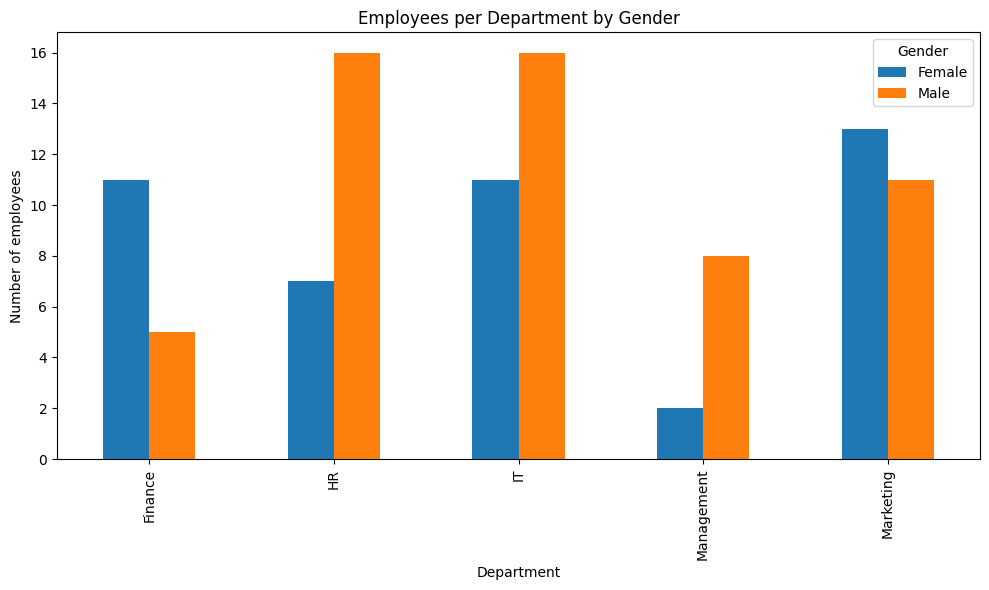

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


dept_gender_count = df.groupby(['Department', 'Gender']).size().reset_index(name='Count')


pivot_table = dept_gender_count.pivot(index='Department', columns='Gender', values='Count')
pivot_table.plot(kind='bar', stacked=False, figsize=(10, 6))

plt.title('Employees per Department by Gender')
plt.xlabel('Department')
plt.ylabel('Number of employees')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()
